In [2]:
import numpy as np
import pandas as pd
import pingouin as pg

import seaborn as sns
from matplotlib import pyplot as plt

# fig5abc

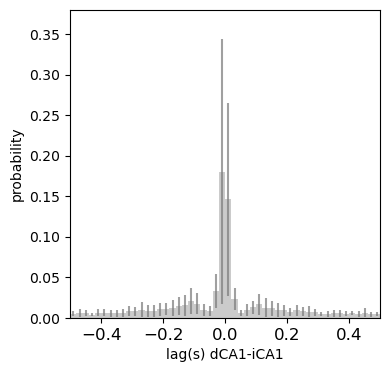

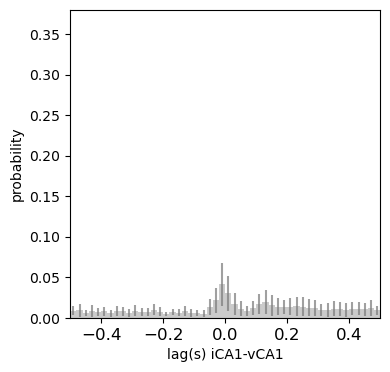

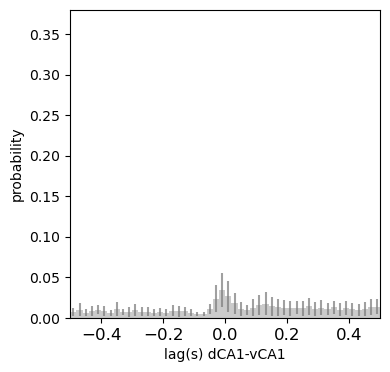

In [19]:
width = 0.02

df = pd.read_parquet('SuppFig5abc.parquet')

for p in range(3):
    a1=df.iloc[p].pair[0]
    a2=df.iloc[p].pair[1]

    fig, ax = plt.subplots(1, 1, figsize=(4,4), sharey=True, sharex=True)
    
    ax.bar( df.iloc[p].time, df.iloc[p].mean_iri,
              width=width,
           yerr= np.vstack( [df.iloc[p].cilow_iri, df.iloc[p].cihigh_iri] ),
#            yerr= summary_IRI['IRI_{}-{}'.format(a1, a2)][events]['std_iri'],
           color='darkgrey', ecolor='grey',
              alpha=0.6, error_kw={'alpha':0.75})

    ax.set(
        # title=events, 
              xlim=(-0.5,0.5),
              ylim=(0,0.38),
              ylabel='probability',
              xlabel='lag(s) {}-{}'.format(a1, a2)
             )

# fig5d

Ext. Data Fig. 5d — Two-way ANOVA: SWR rate ~ subregion × sleep phase
         Source        SS    DF        MS         F     p_unc       np2
0          area  0.009553   2.0  0.004777  1.133180  0.328382  0.034201
1         phase  0.010597   1.0  0.010597  2.514057  0.117764  0.037797
2  area * phase  0.000193   2.0  0.000097  0.022952  0.977318  0.000717
3      Residual  0.269777  64.0  0.004215       NaN       NaN       NaN

       Contrast  area          A         B Paired Parametric         T        dof alternative     p_unc    p_corr p_adjust   BF10     cohen
0          area     -       dCA1      iCA1  False       True -1.011496  37.402385   two-sided  0.318278  0.636556     holm  0.456 -0.307135
1          area     -       dCA1      vCA1  False       True  0.328397  36.242052   two-sided  0.744502  0.744502     holm  0.297  0.097521
2          area     -       iCA1      vCA1  False       True  1.712585  41.578790   two-sided  0.094238  0.282715     holm  0.941  0.499693
3        

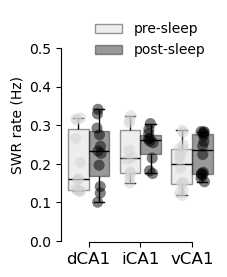

In [4]:
plt.rc('xtick', labelsize=12)

tmp_plot = pd.read_parquet('SuppFig5d.parquet')

fig, ax = plt.subplots(1, 1, figsize=(2, 3))
var = 'swr_rate'

sns.boxplot(x='area', hue='phase', y=var, data=tmp_plot,
            order=['dCA1', 'iCA1', 'vCA1'],
            hue_order=['presleep', 'postsleep'],
            palette=['lightgray', 'black'],
            boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax)
sns.stripplot(x='area', hue='phase', y=var, data=tmp_plot,
              order=['dCA1', 'iCA1', 'vCA1'],
              hue_order=['presleep', 'postsleep'],
              palette=['lightgray', 'black'],
              dodge=True, size=8, alpha=0.5, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['pre-sleep', 'post-sleep'], frameon=False)
ax.set(ylim=(0, 0.6),
       ylabel='SWR rate (Hz)',
       xlabel='')
sns.despine(offset=True, trim=True)

var, factor1, factor2 = 'swr_rate', 'area', 'phase'
data = tmp_plot[[var, factor1, factor2]].copy()
data['group_combined'] = data[factor1] + '_' + data[factor2]

results  = pg.anova(data=data, dv=var, between=[factor1, factor2], ss_type=2)
posthoc1 = pg.pairwise_tests(dv=var, between=[factor1, factor2],
                              padjust='holm', effsize='cohen', data=data)

print("Ext. Data Fig. 5d — Two-way ANOVA: SWR rate ~ subregion × sleep phase")
print(results.to_string())
print()
print(posthoc1.to_string())

# Fig5e

Ext. Data Fig. 5e — Two-way ANOVA: per-unit SWR firing rate ~ subregion × sleep phase
                 Source            SS     DF          MS         F     p_unc       np2
0          cluster_pole    154.228201    2.0   77.114101  2.272837  0.103825  0.006840
1                 phase     42.350945    1.0   42.350945  1.248239  0.264296  0.001888
2  cluster_pole * phase    347.581679    2.0  173.790840  5.122258  0.006202  0.015285
3              Residual  22392.851502  660.0   33.928563       NaN       NaN       NaN

               Contrast  cluster_pole             A             B Paired Parametric         T         dof alternative     p_unc    p_corr p_adjust    BF10     cohen
0          cluster_pole             -        dorsal  intermediate  False       True  1.840885  214.131690   two-sided  0.067022  0.201066     holm   0.583  0.209991
1          cluster_pole             -        dorsal       ventral  False       True  1.604474  251.654527   two-sided  0.109864  0.219728     holm  

/tmp/ipykernel_108701/3777003648.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(0, 65),


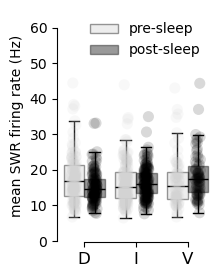

In [7]:
plt.rc('xtick', labelsize=12)

tmp_plot = pd.read_parquet('SuppFig5e.parquet')

fig, ax = plt.subplots(1, 1, figsize=(2, 3))
var = 'mean_SWR_rate'

sns.boxplot(x='cluster_pole', hue='phase', y=var, data=tmp_plot,
            hue_order=['presleep', 'postsleep'],
            palette=['lightgray', 'black'],
            boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax)
sns.stripplot(x='cluster_pole', hue='phase', y=var, data=tmp_plot,
              hue_order=['presleep', 'postsleep'],
              palette=['lightgray', 'black'],
              dodge=True, size=8, alpha=0.15, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['pre-sleep', 'post-sleep'], frameon=False)
ax.set(ylim=(0, 65),
       xticklabels=['D', 'I', 'V'],
       ylabel='mean SWR firing rate (Hz)',
       xlabel='')
sns.despine(offset=True, trim=True)

var, factor1, factor2 = 'mean_SWR_rate', 'cluster_pole', 'phase'
data = tmp_plot[[var, factor1, factor2]].copy()
data['group_combined'] = data[factor1] + '_' + data[factor2]

results  = pg.anova(data=data, dv=var, between=[factor1, factor2], ss_type=2)
posthoc1 = pg.pairwise_tests(dv=var, between=[factor1, factor2],
                              padjust='holm', effsize='cohen', data=data)

print("Ext. Data Fig. 5e — Two-way ANOVA: per-unit SWR firing rate ~ subregion × sleep phase")
print(results.to_string())
print()
print(posthoc1.to_string())

# Fig5f

/tmp/ipykernel_108701/4025319213.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(-0.2, 0.2),


Ext. Data Fig. 5f — Two-way ANOVA: SWR co-activity ~ subregion × sleep phase
         Source        SS    DF        MS         F     p_unc       np2
0         phase  0.001072   1.0  0.001072  0.267581  0.607072  0.004931
1          pole  0.000899   2.0  0.000450  0.112240  0.894038  0.004140
2  phase * pole  0.001809   2.0  0.000904  0.225723  0.798688  0.008291
3      Residual  0.216349  54.0  0.004006       NaN       NaN       NaN

       Contrast      phase                          A                          B Paired Parametric         T        dof alternative     p_unc  p_corr p_adjust   BF10     cohen
0         phase          -                  postsleep                   presleep  False       True  0.532775  58.000000   two-sided  0.596225     NaN      NaN  0.296  0.137562
1          pole          -              dorsal-dorsal  intermediate-intermediate  False       True  0.574037  19.929734   two-sided  0.572365     1.0     holm  0.374  0.205608
2          pole          -        

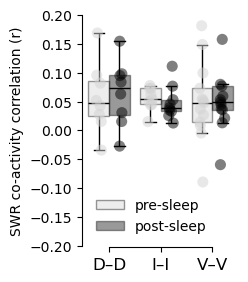

In [11]:
plt.rc('xtick', labelsize=12)

tmp_plot = pd.read_parquet('SuppFig5f.parquet')

fig, ax = plt.subplots(1, 1, figsize=(2, 3))
var = 'correlation'

sns.boxplot(x='pole', hue='phase', y=var, data=tmp_plot,
            order=['dorsal-dorsal', 'intermediate-intermediate', 'ventral-ventral'],
            hue_order=['presleep', 'postsleep'],
            palette=['lightgray', 'black'],
            boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax)
sns.stripplot(x='pole', hue='phase', y=var, data=tmp_plot,
              order=['dorsal-dorsal', 'intermediate-intermediate', 'ventral-ventral'],
              hue_order=['presleep', 'postsleep'],
              palette=['lightgray', 'black'],
              dodge=True, size=8, alpha=0.5, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['pre-sleep', 'post-sleep'], frameon=False)
ax.set(ylim=(-0.2, 0.2),
       xticklabels=['D–D', 'I–I', 'V–V'],
       ylabel='SWR co-activity correlation (r)',
       xlabel='')
sns.despine(offset=True, trim=True)

var, factor1, factor2 = 'correlation', 'phase', 'pole'
data = tmp_plot[[var, factor1, factor2]].copy()
data['group_combined'] = data[factor1] + '_' + data[factor2]

results  = pg.anova(data=data, dv=var, between=[factor1, factor2], ss_type=2)
posthoc1 = pg.pairwise_tests(dv=var, between=[factor1, factor2],
                              padjust='holm', effsize='cohen', data=data)

print("Ext. Data Fig. 5f — Two-way ANOVA: SWR co-activity ~ subregion × sleep phase")
print(results.to_string())
print()
print(posthoc1.to_string())